In [3]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.home() / 'mece_project_inverse_model' / 'Generative_Inverse_Design_of_High-Speed_Interconnects'
PT_PATH = PROJECT_ROOT / 'data' / 'processed' / 'Universal-Diff-SI-Array' / 'diff_pair_dataset.pt'
RAW_ROOT = PROJECT_ROOT / 'data' / 'raw' / 'Universal-Diff-SI-Array'
CSV_PATH = RAW_ROOT / 'parameter.csv'

assert PT_PATH.exists(), f'.pt not found: {PT_PATH}'
assert CSV_PATH.exists(), f'CSV not found: {CSV_PATH}'

payload = torch.load(PT_PATH, weights_only=False)
print(f'Loaded payload from {PT_PATH}')
print(f'Size on disk: {PT_PATH.stat().st_size / 1e6:.1f} MB')

Loaded payload from /home/dhanushkramesh/mece_project_inverse_model/Generative_Inverse_Design_of_High-Speed_Interconnects/data/processed/Universal-Diff-SI-Array/diff_pair_dataset.pt
Size on disk: 618.1 MB


In [4]:
# 1.1 — Top-level keys present and types correct
EXPECTED_TENSOR_KEYS = {
    'X_local': ((None, 8), torch.float32),
    'X_global': ((None, 6), torch.float32),
    'X_context': ((None, 7), torch.float32),
    'Y_real': ((None, 401, 4, 4), torch.float32),
    'Y_imag': ((None, 401, 4, 4), torch.float32),
    'pair_ids': ((None,), torch.int64),
    'num_ports': ((None,), torch.int64),
    'X_local_mean': ((8,), torch.float32),
    'X_local_std': ((8,), torch.float32),
    'X_global_mean': ((6,), torch.float32),
    'X_global_std': ((6,), torch.float32),
    'X_context_mean': ((7,), torch.float32),
    'X_context_std': ((7,), torch.float32),
    'frequencies': ((401,), torch.float64),
}

N = payload['X_local'].shape[0]
print(f'N (pairs) = {N}')

failures = []
for k, (expected_shape, expected_dtype) in EXPECTED_TENSOR_KEYS.items():
    if k not in payload:
        failures.append(f'MISSING key: {k}')
        continue
    t = payload[k]
    actual_shape = tuple(t.shape)
    target = tuple(N if s is None else s for s in expected_shape)
    if actual_shape != target:
        failures.append(f'{k}: shape {actual_shape} != {target}')
    if t.dtype != expected_dtype:
        failures.append(f'{k}: dtype {t.dtype} != {expected_dtype}')

assert payload['dataset_type'] == 'Array', f'dataset_type wrong: {payload["dataset_type"]}'
assert len(payload['sim_ids']) == N
assert isinstance(payload['sim_ids'][0], str)

if failures:
    for f in failures:
        print('  FAIL:', f)
    raise AssertionError(f'{len(failures)} schema failure(s)')
print('Section 1.1 OK — all tensor shapes and dtypes match the contract')

N (pairs) = 12017
Section 1.1 OK — all tensor shapes and dtypes match the contract


In [5]:
# 1.2 — Feature name lists match the contract
EXPECTED_LOCAL = ['VIA_RADIUS', 'ANTIPAD_RADIUS', 'PITCH', 'TDIEL', 'TMET', 'PERMITTIVITY', 'CONDUCTIVITY', 'LOSSTANGENT']
EXPECTED_GLOBAL = ['LAYER_AMOUNT', 'VIAS_X_AMOUNT', 'VIAS_Y_AMOUNT', 'SIGNAL_AMOUNT', 'GROUND_AMOUNT', 'POWER_AMOUNT']
EXPECTED_CONTEXT = ['pair_x', 'pair_y', 'n_gnd_within_1_pitch', 'n_gnd_within_2_pitches', 'n_pwr_within_2_pitches', 'n_other_sgn_within_2_pitches', 'dist_to_array_edge']
EXPECTED_LOG = ['CONDUCTIVITY', 'LOSSTANGENT']

assert payload['local_features'] == EXPECTED_LOCAL, payload['local_features']
assert payload['global_features'] == EXPECTED_GLOBAL, payload['global_features']
assert payload['context_features'] == EXPECTED_CONTEXT, payload['context_features']
assert payload['log_features'] == EXPECTED_LOG, payload['log_features']
print('Section 1.2 OK — feature names match contract exactly')

Section 1.2 OK — feature names match contract exactly


In [6]:
# 1.3 — No NaN / Inf anywhere
for k in ['X_local', 'X_global', 'X_context', 'Y_real', 'Y_imag']:
    t = payload[k]
    n_nan = torch.isnan(t).sum().item()
    n_inf = torch.isinf(t).sum().item()
    print(f'  {k:10s}  NaN={n_nan}  Inf={n_inf}  min={t.min().item():.3e}  max={t.max().item():.3e}')
    assert n_nan == 0, f'{k} contains NaN'
    assert n_inf == 0, f'{k} contains Inf'
print('Section 1.3 OK — no NaN/Inf in any tensor')

  X_local     NaN=0  Inf=0  min=-4.548e+00  max=2.914e+00
  X_global    NaN=0  Inf=0  min=-2.052e+00  max=4.341e+00
  X_context   NaN=0  Inf=0  min=-2.320e+00  max=5.151e+00
  Y_real      NaN=0  Inf=0  min=-9.978e-01  max=1.000e+00
  Y_imag      NaN=0  Inf=0  min=-9.987e-01  max=9.969e-01
Section 1.3 OK — no NaN/Inf in any tensor


In [7]:
# 1.4 — Z-score stats are sane (mean != std unless feature truly is degenerate)
# If mean == std for ALL features, that would be the smoking gun for the bug you almost printed.
for grp in ['local', 'global', 'context']:
    mu = payload[f'X_{grp}_mean']
    sd = payload[f'X_{grp}_std']
    print(f'\n{grp}:')
    names = payload[f'{grp}_features']
    for name, m, s in zip(names, mu.tolist(), sd.tolist()):
        flag = '  <-- DEGENERATE' if s < 1e-8 else ''
        print(f'  {name:35s}  mean={m:12.4g}  std={s:12.4g}{flag}')
    assert (sd > 0).all(), f'{grp} has zero-std feature (would NaN the z-score)'
    # mean ≠ std for at least one feature: if all were equal that'd be the smoking gun
    assert not torch.allclose(mu, sd), f'{grp}: mean == std elementwise (suspicious)'
print('\nSection 1.4 OK — stats look healthy')


local:
  VIA_RADIUS                           mean=       10.22  std=       4.662
  ANTIPAD_RADIUS                       mean=        22.5  std=        5.55
  PITCH                                mean=        54.8  std=       8.545
  TDIEL                                mean=       41.97  std=       21.95
  TMET                                 mean=       2.403  std=      0.9792
  PERMITTIVITY                         mean=       3.612  std=      0.6415
  CONDUCTIVITY                         mean=       7.688  std=     0.04687
  LOSSTANGENT                          mean=      -1.944  std=      0.4055

global:
  LAYER_AMOUNT                         mean=       25.76  std=       12.74
  VIAS_X_AMOUNT                        mean=       5.173  std=        1.33
  VIAS_Y_AMOUNT                        mean=       5.197  std=       1.325
  SIGNAL_AMOUNT                        mean=       12.62  std=       5.173
  GROUND_AMOUNT                        mean=       11.56  std=       4.708
  POWER_

In [8]:
# 1.5 — Frequency grid
freq = payload['frequencies'].numpy()
assert freq[0] == 250e6, freq[0]
assert freq[-1] == 100e9, freq[-1]
df = np.diff(freq)
assert np.allclose(df, df[0], rtol=1e-9), 'frequency grid is not linearly spaced'
print(f'  freq[0]   = {freq[0]:.3e} Hz')
print(f'  freq[-1]  = {freq[-1]:.3e} Hz')
print(f'  step      = {df[0]:.3e} Hz ({len(freq)} points)')
print('Section 1.5 OK — frequency grid is 0.25-100 GHz, 401 linear points')

  freq[0]   = 2.500e+08 Hz
  freq[-1]  = 1.000e+11 Hz
  step      = 2.494e+08 Hz (401 points)
Section 1.5 OK — frequency grid is 0.25-100 GHz, 401 linear points


In [9]:
# 1.6 — sim_id / num_ports consistency. All pairs from one sim must share num_ports.
sim_ids_arr = np.array(payload['sim_ids'])
nports = payload['num_ports'].numpy()
df_sim = pd.DataFrame({'sim_id': sim_ids_arr, 'num_ports': nports, 'pair_id': payload['pair_ids'].numpy()})

n_unique_sims = df_sim['sim_id'].nunique()
print(f'  unique sim_ids: {n_unique_sims}')
print(f'  pairs/sim: min={df_sim.groupby("sim_id").size().min()}, max={df_sim.groupby("sim_id").size().max()}')

# Each sim must have a single value of num_ports
ports_per_sim = df_sim.groupby('sim_id')['num_ports'].nunique()
assert (ports_per_sim == 1).all(), f'{(ports_per_sim != 1).sum()} sims have inconsistent num_ports'

# pair_id must be 1..K within each sim, where K = pairs from that sim = num_ports/4 for Array
for sid, grp in df_sim.groupby('sim_id'):
    n_pairs_actual = len(grp)
    n_ports = grp['num_ports'].iloc[0]
    n_pairs_expected = n_ports // 4
    assert n_pairs_actual == n_pairs_expected, f'{sid}: {n_pairs_actual} pairs but expected {n_pairs_expected} (ports={n_ports})'
    assert sorted(grp['pair_id'].tolist()) == list(range(1, n_pairs_actual + 1)), f'{sid}: pair_ids not 1..{n_pairs_actual}'
print('Section 1.6 OK — sim_id / num_ports / pair_id structure consistent')

  unique sim_ids: 1905
  pairs/sim: min=1, max=14
Section 1.6 OK — sim_id / num_ports / pair_id structure consistent


In [13]:
# Section 2 — De-normalization round-trip
csv = pd.read_csv(CSV_PATH)
# Normalize header casing & known typo (handover noted LOSTANGENT in some variants)
csv.columns = [c.replace('LOSTANGENT', 'LOSSTANGENT') for c in csv.columns]
SIM_COL = 'SIMULATION'  # confirmed: column of 'sim_pkg_NNNN' strings
assert SIM_COL in csv.columns, f'{SIM_COL} not in CSV columns: {list(csv.columns)}'
print(f'CSV: {len(csv)} rows, sim-id column = {SIM_COL!r}')

CSV: 1916 rows, sim-id column = 'SIMULATION'


In [14]:
# Pick a random pair, de-normalize, compare to CSV
rng = np.random.default_rng(seed=42)
idx = int(rng.integers(0, N))
sid = payload['sim_ids'][idx]
pid = int(payload['pair_ids'][idx].item())
print(f'Auditing pair: index={idx}  sim_id={sid}  pair_id={pid}')

# Reverse the z-score on X_local
x_local_z = payload['X_local'][idx]
x_local_recovered = (x_local_z * payload['X_local_std'] + payload['X_local_mean']).numpy().copy()

# Undo log10 on the log_features columns
local_names = payload['local_features']
log_names = payload['log_features']
for lname in log_names:
    i_col = local_names.index(lname)
    x_local_recovered[i_col] = 10 ** x_local_recovered[i_col]

# Look up the CSV row for this sim_id
csv_row = csv[csv[SIM_COL] == sid]
assert len(csv_row) == 1, f'Found {len(csv_row)} rows for {sid} in column {SIM_COL}'
csv_row = csv_row.iloc[0]

# Compare X_local
print(f'\nX_local round-trip:')
print(f'{"feature":20s} {"recovered":>15s} {"csv":>15s} {"rel_err":>12s}')
print('-' * 65)
max_rel_err = 0.0
for name, val_rec in zip(local_names, x_local_recovered):
    val_csv = float(csv_row[name])
    rel = abs(val_rec - val_csv) / max(abs(val_csv), 1e-30)
    max_rel_err = max(max_rel_err, rel)
    print(f'{name:20s} {val_rec:15.6g} {val_csv:15.6g} {rel:12.2e}')

# Also round-trip X_global as a bonus check
x_global_z = payload['X_global'][idx]
x_global_recovered = (x_global_z * payload['X_global_std'] + payload['X_global_mean']).numpy()
print(f'\nX_global round-trip:')
print(f'{"feature":20s} {"recovered":>15s} {"csv":>15s} {"rel_err":>12s}')
print('-' * 65)
for name, val_rec in zip(payload['global_features'], x_global_recovered):
    val_csv = float(csv_row[name])
    rel = abs(val_rec - val_csv) / max(abs(val_csv), 1e-30)
    max_rel_err = max(max_rel_err, rel)
    print(f'{name:20s} {val_rec:15.6g} {val_csv:15.6g} {rel:12.2e}')

print(f'\nMax relative error: {max_rel_err:.2e}')
assert max_rel_err < 1e-4, f'De-normalization round-trip failed at {max_rel_err:.2e}'
print('Section 2 OK — z-score and log10 transforms round-trip cleanly for X_local and X_global')

Auditing pair: index=1072  sim_id=sim_pkg_0821  pair_id=8

X_local round-trip:
feature                    recovered             csv      rel_err
-----------------------------------------------------------------
VIA_RADIUS                   12.5446         12.5446     7.60e-08
ANTIPAD_RADIUS               18.7474         18.7474     0.00e+00
PITCH                        51.2872         51.2872     7.44e-08
TDIEL                        42.3409         42.3409     0.00e+00
TMET                         3.50123         3.50123     0.00e+00
PERMITTIVITY                 3.04929         3.04929     7.82e-08
CONDUCTIVITY             4.15032e+07     4.15031e+07     9.64e-08
LOSSTANGENT               0.00371672      0.00371672     0.00e+00

X_global round-trip:
feature                    recovered             csv      rel_err
-----------------------------------------------------------------
LAYER_AMOUNT                       4               4     4.77e-07
VIAS_X_AMOUNT                      5     

In [15]:
# Bockelman-Eisenstadt: confirm Y storage is mixed-mode. Sdd21 is index [1,0] in MM ordering [DD11,DD12,DD21,DD22 / DC.../CD.../CC...].
# Per the contract Y is already mixed-mode, with M = (1/√2) [[1,-1,0,0],[0,0,1,-1],[1,1,0,0],[0,0,1,1]].
# Differential block is the top-left 2x2: Sdd11 = Y[:,:,0,0], Sdd21 = Y[:,:,1,0].

def get_sdd21(Yr, Yi, pair_indices):
    """Sdd21 magnitude in dB across frequency for the given pair rows."""
    s = Yr[pair_indices, :, 1, 0] + 1j * Yi[pair_indices, :, 1, 0]
    return 20 * np.log10(np.abs(s) + 1e-30)

def get_sdd11(Yr, Yi, pair_indices):
    s = Yr[pair_indices, :, 0, 0] + 1j * Yi[pair_indices, :, 0, 0]
    return 20 * np.log10(np.abs(s) + 1e-30)

Yr = payload['Y_real'].numpy()
Yi = payload['Y_imag'].numpy()
freq_ghz = freq / 1e9

# Verify X_local and X_global are identical across pairs within a sim
df_sim_lookup = pd.DataFrame({'sim_id': sim_ids_arr, 'row': np.arange(N)})
for sid in df_sim_lookup['sim_id'].drop_duplicates().sample(5, random_state=0):
    rows = df_sim_lookup.loc[df_sim_lookup['sim_id'] == sid, 'row'].values
    if len(rows) < 2:
        continue
    xl = payload['X_local'][rows]
    xg = payload['X_global'][rows]
    xc = payload['X_context'][rows]
    same_local = torch.allclose(xl, xl[:1].expand_as(xl), atol=1e-6)
    same_global = torch.allclose(xg, xg[:1].expand_as(xg), atol=1e-6)
    diff_context_rows = (xc - xc[:1]).abs().sum(dim=1) > 1e-6
    pct_distinct_context = 100 * diff_context_rows.sum().item() / (len(rows) - 1)
    print(f'  {sid}: {len(rows)} pairs | X_local same={same_local} | X_global same={same_global} | distinct X_context rows={pct_distinct_context:.0f}%')
    assert same_local, f'{sid}: X_local differs across pairs (BUG)'
    assert same_global, f'{sid}: X_global differs across pairs (BUG)'
print('Section 3.1 OK — X_local and X_global constant within sim, X_context varies')

  sim_pkg_2310: 9 pairs | X_local same=True | X_global same=True | distinct X_context rows=100%
  sim_pkg_0287: 6 pairs | X_local same=True | X_global same=True | distinct X_context rows=100%
  sim_pkg_4117: 4 pairs | X_local same=True | X_global same=True | distinct X_context rows=100%
  sim_pkg_9272: 3 pairs | X_local same=True | X_global same=True | distinct X_context rows=100%
  sim_pkg_4137: 7 pairs | X_local same=True | X_global same=True | distinct X_context rows=100%
Section 3.1 OK — X_local and X_global constant within sim, X_context varies


/tmp/ipykernel_28343/3496131274.py:24: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  xl = payload['X_local'][rows]


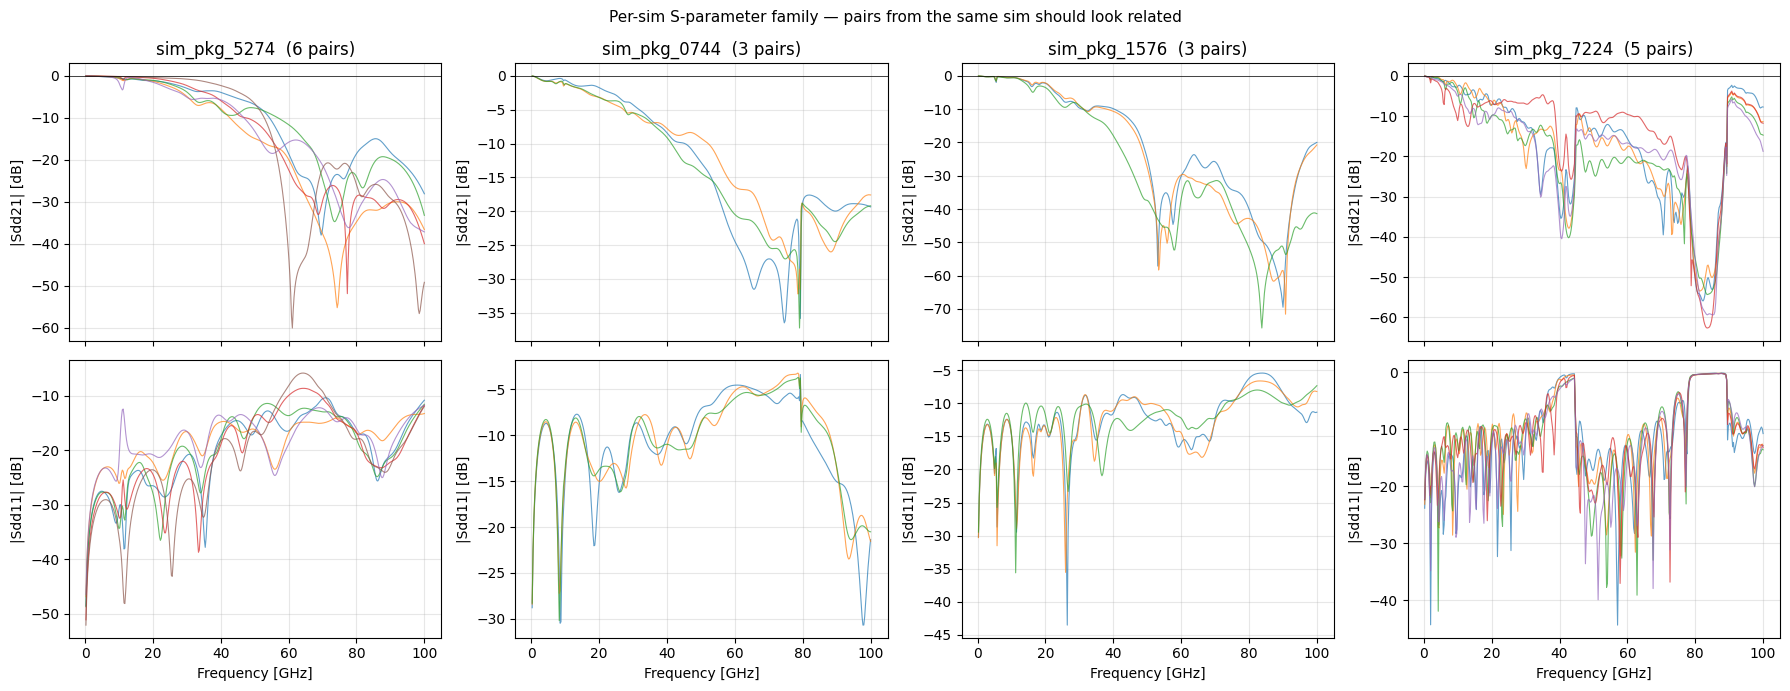

Section 3.2 — visual check: pairs of one sim should cluster, not scatter


In [16]:
# 3.2 — Plot Sdd21 / Sdd11 for all pairs of 4 random sims. Should look like a family.
sample_sims = (df_sim_lookup['sim_id'].drop_duplicates()
                  .sample(4, random_state=1).tolist())

fig, axes = plt.subplots(2, 4, figsize=(18, 7), sharex=True)
for col, sid in enumerate(sample_sims):
    rows = df_sim_lookup.loc[df_sim_lookup['sim_id'] == sid, 'row'].values
    sdd21_db = get_sdd21(Yr, Yi, rows)
    sdd11_db = get_sdd11(Yr, Yi, rows)
    for r in range(len(rows)):
        axes[0, col].plot(freq_ghz, sdd21_db[r], alpha=0.7, linewidth=0.8)
        axes[1, col].plot(freq_ghz, sdd11_db[r], alpha=0.7, linewidth=0.8)
    axes[0, col].set_title(f'{sid}  ({len(rows)} pairs)')
    axes[0, col].set_ylabel('|Sdd21| [dB]')
    axes[1, col].set_ylabel('|Sdd11| [dB]')
    axes[1, col].set_xlabel('Frequency [GHz]')
    axes[0, col].grid(True, alpha=0.3)
    axes[1, col].grid(True, alpha=0.3)
    axes[0, col].axhline(0, color='k', linewidth=0.5)
plt.suptitle('Per-sim S-parameter family — pairs from the same sim should look related', fontsize=11)
plt.tight_layout()
plt.show()
print('Section 3.2 — visual check: pairs of one sim should cluster, not scatter')

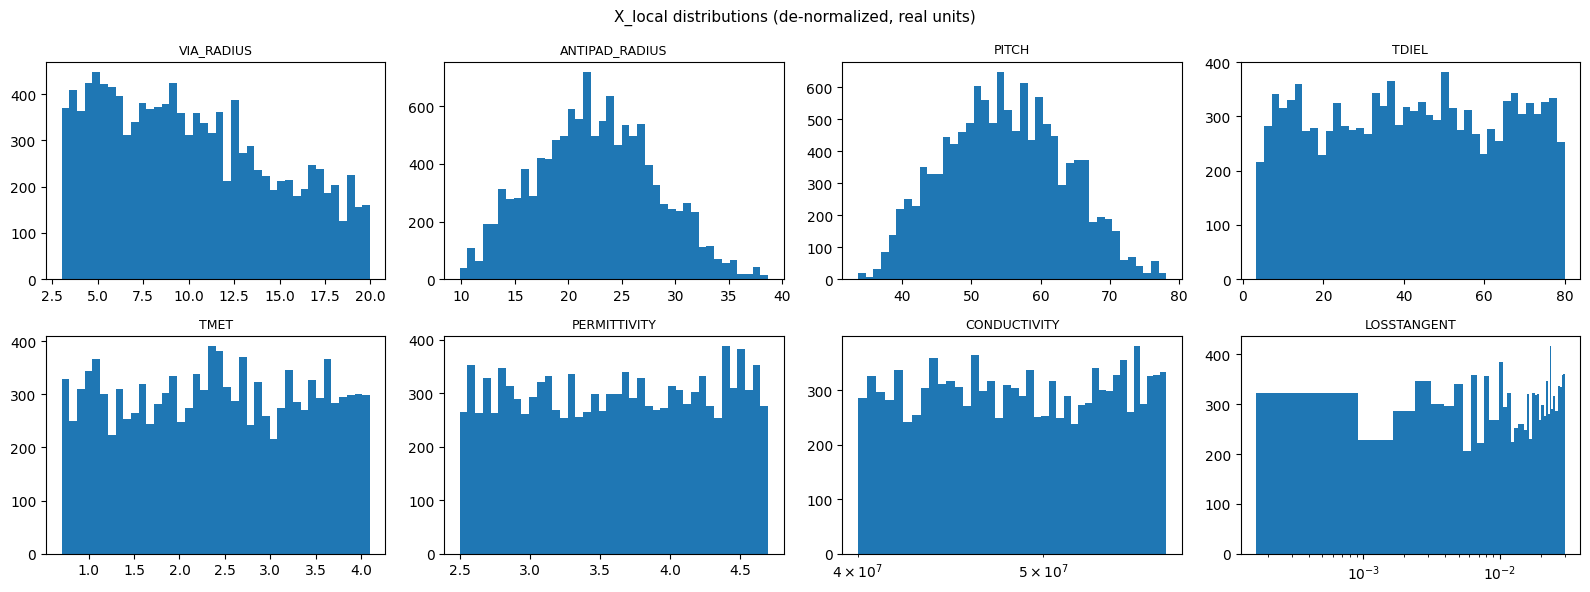

Unique value counts (sanity: integers should be small, continuous LHS large):
  VIA_RADIUS            unique= 1904  range=[3, 20]
  ANTIPAD_RADIUS        unique= 1905  range=[9.85, 38.7]
  PITCH                 unique= 1904  range=[33.6, 78.2]
  TDIEL                 unique= 1905  range=[3.29, 80]
  TMET                  unique= 1905  range=[0.7, 4.1]
  PERMITTIVITY          unique= 1905  range=[2.5, 4.7]
  CONDUCTIVITY          unique= 1905  range=[4e+07, 5.8e+07]
  LOSSTANGENT           unique= 1900  range=[0.000163, 0.03]


In [17]:
# 4.1 — Distributions of X_local (de-normalized + log undone)
x_local_full = (payload['X_local'] * payload['X_local_std'] + payload['X_local_mean']).numpy()
for lname in log_names:
    i = local_names.index(lname)
    x_local_full[:, i] = 10 ** x_local_full[:, i]

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
for ax, name, col in zip(axes.flat, local_names, x_local_full.T):
    ax.hist(col, bins=40, edgecolor='none')
    ax.set_title(name, fontsize=9)
    if name in log_names:
        ax.set_xscale('log')
plt.suptitle('X_local distributions (de-normalized, real units)', fontsize=11)
plt.tight_layout()
plt.show()

print('Unique value counts (sanity: integers should be small, continuous LHS large):')
for name, col in zip(local_names, x_local_full.T):
    print(f'  {name:20s}  unique={len(np.unique(np.round(col, 6))):5d}  range=[{col.min():.3g}, {col.max():.3g}]')

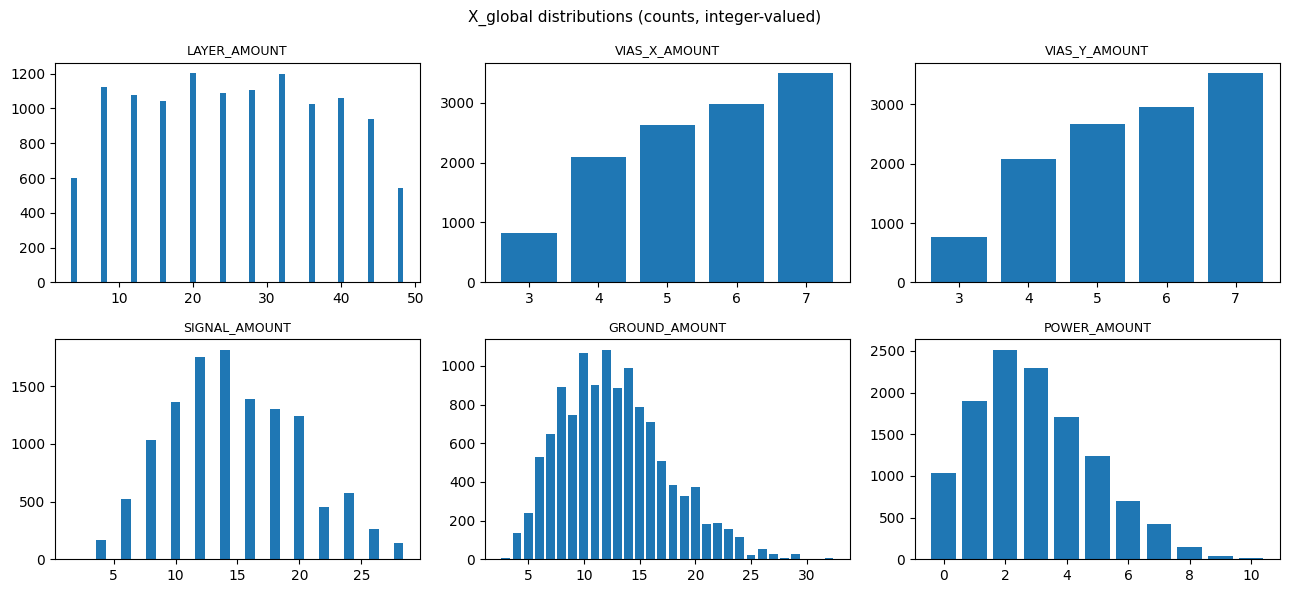

In [18]:
# 4.2 — Distributions of X_global (counts: should be small unique sets)
x_global_full = (payload['X_global'] * payload['X_global_std'] + payload['X_global_mean']).numpy()

fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for ax, name, col in zip(axes.flat, payload['global_features'], x_global_full.T):
    vals = np.round(col).astype(int)
    uniq, counts = np.unique(vals, return_counts=True)
    ax.bar(uniq, counts)
    ax.set_title(name, fontsize=9)
plt.suptitle('X_global distributions (counts, integer-valued)', fontsize=11)
plt.tight_layout()
plt.show()

In [19]:
# 4.3 — Y magnitude statistics
Y_mag = np.sqrt(Yr**2 + Yi**2)
print(f'  |Y| min        = {Y_mag.min():.3e}')
print(f'  |Y| max        = {Y_mag.max():.3e}')
print(f'  |Y| mean       = {Y_mag.mean():.3e}')
print(f'  pct |Y| > 1    = {100*(Y_mag > 1).mean():.4f}%')
print(f'  pct |Y| > 1.01 = {100*(Y_mag > 1.01).mean():.4f}%')
# Mixed-mode |Sij| can briefly exceed 1 at the boundary of numerical noise. Anything above 1.01 is a real issue.
assert (Y_mag > 1.01).mean() < 1e-4, 'Too many entries exceed |S| = 1.01 — passivity smell'
print('Section 4.3 OK — Y magnitudes within physical range')

  |Y| min        = 1.315e-20
  |Y| max        = 1.000e+00
  |Y| mean       = 1.790e-01
  pct |Y| > 1    = 0.0000%
  pct |Y| > 1.01 = 0.0000%
Section 4.3 OK — Y magnitudes within physical range


In [20]:
rng = np.random.default_rng(seed=7)
sample_rows = rng.choice(N, size=min(200, N), replace=False)

# 5.1 — Sdd21 at DC
sdd21_dc_db = get_sdd21(Yr, Yi, sample_rows)[:, 0]
print(f'Sdd21(DC) [dB] over {len(sample_rows)} pairs: mean={sdd21_dc_db.mean():.3f}, p1={np.percentile(sdd21_dc_db, 1):.3f}, p99={np.percentile(sdd21_dc_db, 99):.3f}')
# Handover says ~-0.03 dB; allow generous tolerance for diff-pairs in messy arrays.
assert abs(sdd21_dc_db.mean()) < 1.0, f'Sdd21(DC) mean far from 0 dB: {sdd21_dc_db.mean()}'
print('Section 5.1 OK — Sdd21(DC) close to 0 dB')

# 5.2 — |Sdd21| <= 1 everywhere
Sdd21_complex = Yr[sample_rows, :, 1, 0] + 1j * Yi[sample_rows, :, 1, 0]
max_abs_sdd21 = np.abs(Sdd21_complex).max()
print(f'  max |Sdd21| over sample = {max_abs_sdd21:.6f}')
assert max_abs_sdd21 < 1.001, f'|Sdd21| > 1 at {max_abs_sdd21}'
print('Section 5.2 OK — |Sdd21| <= 1')

Sdd21(DC) [dB] over 200 pairs: mean=-0.030, p1=-0.238, p99=-0.000
Section 5.1 OK — Sdd21(DC) close to 0 dB
  max |Sdd21| over sample = 0.999994
Section 5.2 OK — |Sdd21| <= 1


In [21]:
# 5.3 — Reciprocity (passive linear → S = S^T)
S_sample = Yr[sample_rows] + 1j * Yi[sample_rows]  # (M, 401, 4, 4)
asym = np.abs(S_sample - np.transpose(S_sample, (0, 1, 3, 2)))
max_asym = asym.max()
mean_asym = asym.mean()
print(f'  max |S - S^T| = {max_asym:.3e}')
print(f'  mean|S - S^T| = {mean_asym:.3e}')
# Generous tol — Bockelman-Eisenstadt transform is exact but EM solver outputs aren't perfectly reciprocal.
assert max_asym < 1e-2, f'Reciprocity violation: max asym = {max_asym}'
print('Section 5.3 OK — mixed-mode S is approximately reciprocal')

# 5.4 — Passivity via SVD: σ_max(S(f)) <= 1
M = S_sample.shape[0]
# Take a subset of frequencies to keep SVD fast: every 20th point = 21 freqs
freq_idx = np.arange(0, 401, 20)
S_sub = S_sample[:, freq_idx]  # (M, 21, 4, 4)
sv = np.linalg.svd(S_sub, compute_uv=False)  # (M, 21, 4)
max_sv = sv.max()
frac_violations = (sv > 1.001).mean()
print(f'  max sigma(S) over sample = {max_sv:.6f}')
print(f'  fraction(sigma > 1.001)  = {frac_violations:.6f}')
# Sub-network of full N-port can have σ slightly > 1 (Triverio §4.2); tolerate up to ~1.05 in rare cases
assert max_sv < 1.05, f'Severe passivity violation: max σ = {max_sv}'
print('Section 5.4 OK — passivity bounded')

  max |S - S^T| = 0.000e+00
  mean|S - S^T| = 0.000e+00
Section 5.3 OK — mixed-mode S is approximately reciprocal
  max sigma(S) over sample = 1.000000
  fraction(sigma > 1.001)  = 0.000000
Section 5.4 OK — passivity bounded


In [22]:
print('=' * 60)
print('AUDIT PASSED — Array .pt is training-ready')
print('=' * 60)
print(f'N pairs: {N}')
print(f'N sims: {n_unique_sims}')
print(f'Feature dims: local={payload["X_local"].shape[1]}, global={payload["X_global"].shape[1]}, context={payload["X_context"].shape[1]}')
print(f'Y shape: {tuple(payload["Y_real"].shape)} (real + imag, mixed-mode)')
print(f'Freq: 0.25-100 GHz, 401 points')

AUDIT PASSED — Array .pt is training-ready
N pairs: 12017
N sims: 1905
Feature dims: local=8, global=6, context=7
Y shape: (12017, 401, 4, 4) (real + imag, mixed-mode)
Freq: 0.25-100 GHz, 401 points
